# Financial News Exploratory Data Analysis

## Week 1 Challenge — Nova Financial Solutions

This notebook explores:
- financial news headlines
- publisher activity
- publication trends
- keyword patterns
- topic distributions
- sentiment indicators

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

import nltk
from nltk.corpus import stopwords

In [26]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\nfepo\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [27]:
news_df = pd.read_csv("../data/raw/raw_analyst_ratings_compressed.csv")

news_df.head()

ParserError: Error tokenizing data. C error: Expected 6 fields in line 910, saw 7


In [ ]:
news_df = pd.read_csv(
    "../data/raw/raw_analyst_ratings_compressed.csv",
    engine="python",
    on_bad_lines="skip"
)

news_df.head()

,Unnamed: 0,headline,url,publisher,dt,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,20200605,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,20200603,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,20200526,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,20200522,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,20200522,A


In [ ]:
news_df.shape

(1403295, 6)

In [ ]:
news_df.columns

Index(['Unnamed: 0', 'headline', 'url', 'publisher', 'dt', 'stock'], dtype='str')

In [ ]:
news_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1403295 entries, 0 to 1403294
Data columns (total 6 columns):
 #   Column      Non-Null Count    Dtype
---  ------      --------------    -----
 0   Unnamed: 0  1403295 non-null  int64
 1   headline    1403295 non-null  str  
 2   url         1403295 non-null  str  
 3   publisher   1403295 non-null  str  
 4   dt          1403295 non-null  int64
 5   stock       1403295 non-null  str  
dtypes: int64(2), str(4)
memory usage: 64.2 MB


In [ ]:
'dt'

'dt'

In [ ]:
news_df.drop(columns=['Unnamed: 0'], inplace=True)

In [ ]:
news_df.isnull().sum()

headline     0
url          0
publisher    0
dt           0
stock        0
dtype: int64

In [ ]:
news_df['headline_length'] = news_df['headline'].astype(str).apply(len)

news_df['headline_length'].describe()

count    1.403295e+06
mean     7.301208e+01
std      4.060745e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.090000e+02
Name: headline_length, dtype: float64

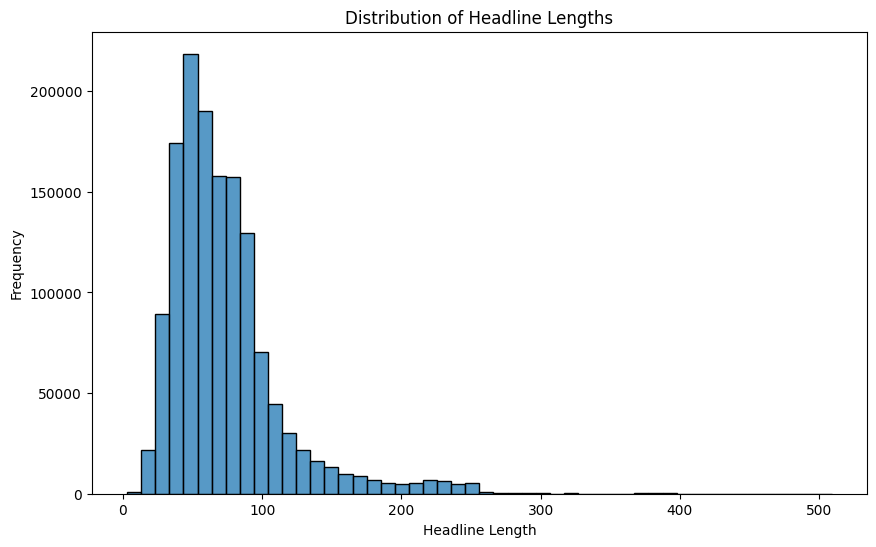

In [ ]:
plt.figure(figsize=(10,6))

sns.histplot(news_df['headline_length'], bins=50)

plt.title("Distribution of Headline Lengths")
plt.xlabel("Headline Length")
plt.ylabel("Frequency")

plt.show()

In [ ]:
publisher_counts = news_df['publisher'].value_counts()

publisher_counts.head(10)

publisher
Paul Quintaro        227837
Lisa Levin           186969
Benzinga Newsdesk    149950
Charles Gross         96516
Monica Gerson         82319
Eddie Staley          57019
Hal Lindon            48722
Juan Lopez            28436
ETF Professor         28385
Benzinga Staff        27929
Name: count, dtype: int64

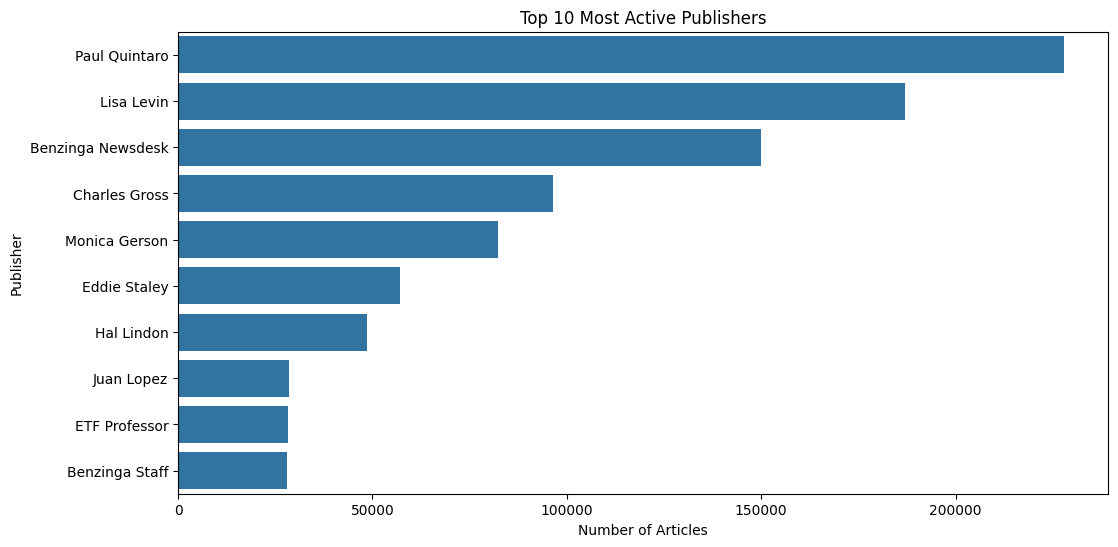

In [ ]:
top_publishers = publisher_counts.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_publishers.values,
    y=top_publishers.index
)

plt.title("Top 10 Most Active Publishers")
plt.xlabel("Number of Articles")
plt.ylabel("Publisher")

plt.show()

In [ ]:
news_df['dt'] = pd.to_datetime(news_df['dt'], errors='coerce')

In [ ]:
news_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1403295 entries, 0 to 1403294
Data columns (total 6 columns):
 #   Column           Non-Null Count    Dtype         
---  ------           --------------    -----         
 0   headline         1403295 non-null  str           
 1   url              1403295 non-null  str           
 2   publisher        1403295 non-null  str           
 3   dt               1403295 non-null  datetime64[ns]
 4   stock            1403295 non-null  str           
 5   headline_length  1403295 non-null  int64         
dtypes: datetime64[ns](1), int64(1), str(4)
memory usage: 64.2 MB


In [ ]:
daily_news = news_df.groupby(news_df['dt'].dt.date).size()

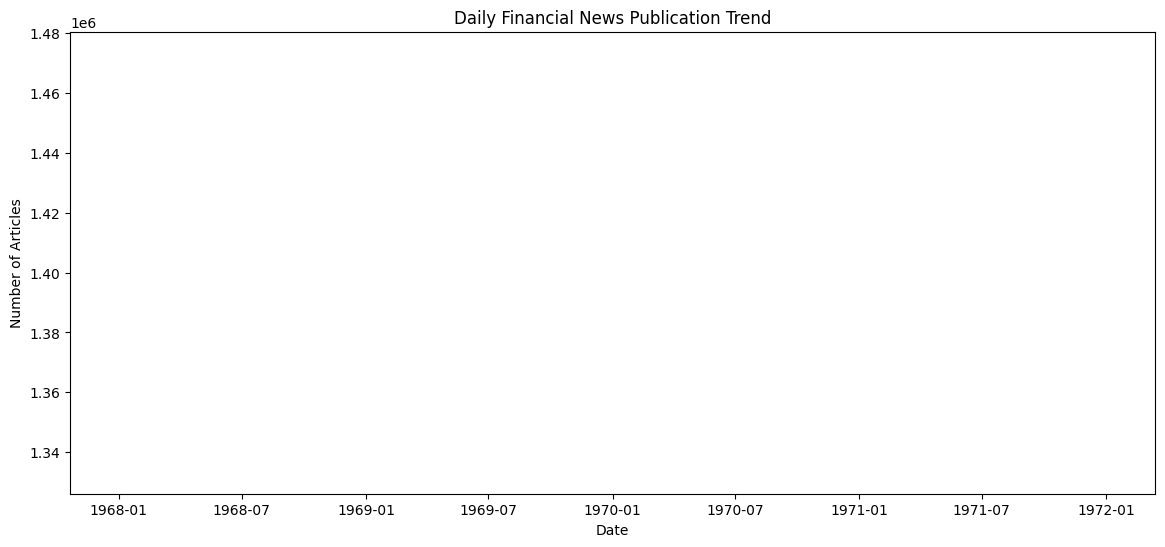

In [ ]:
plt.figure(figsize=(14,6))

daily_news.plot()

plt.title("Daily Financial News Publication Trend")
plt.xlabel("Date")
plt.ylabel("Number of Articles")

plt.show()

In [ ]:
news_df['dt'].head()

0   1970-01-01 00:00:00.020200605
1   1970-01-01 00:00:00.020200603
2   1970-01-01 00:00:00.020200526
3   1970-01-01 00:00:00.020200522
4   1970-01-01 00:00:00.020200522
Name: dt, dtype: datetime64[ns]

In [ ]:
news_df['dt'].sample(5)

701449   1970-01-01 00:00:00.020190826
459289   1970-01-01 00:00:00.020160808
596139   1970-01-01 00:00:00.020190128
484319   1970-01-01 00:00:00.020131114
404776   1970-01-01 00:00:00.020120606
Name: dt, dtype: datetime64[ns]

In [ ]:
news_df['dt'] = pd.to_datetime(
    news_df['dt'],
    errors='coerce',
    utc=True
)

In [ ]:
news_df['dt'].isnull().sum()

np.int64(0)

In [ ]:
news_df = news_df.dropna(subset=['dt'])

In [ ]:
daily_news = news_df.groupby(news_df['dt'].dt.date).size()

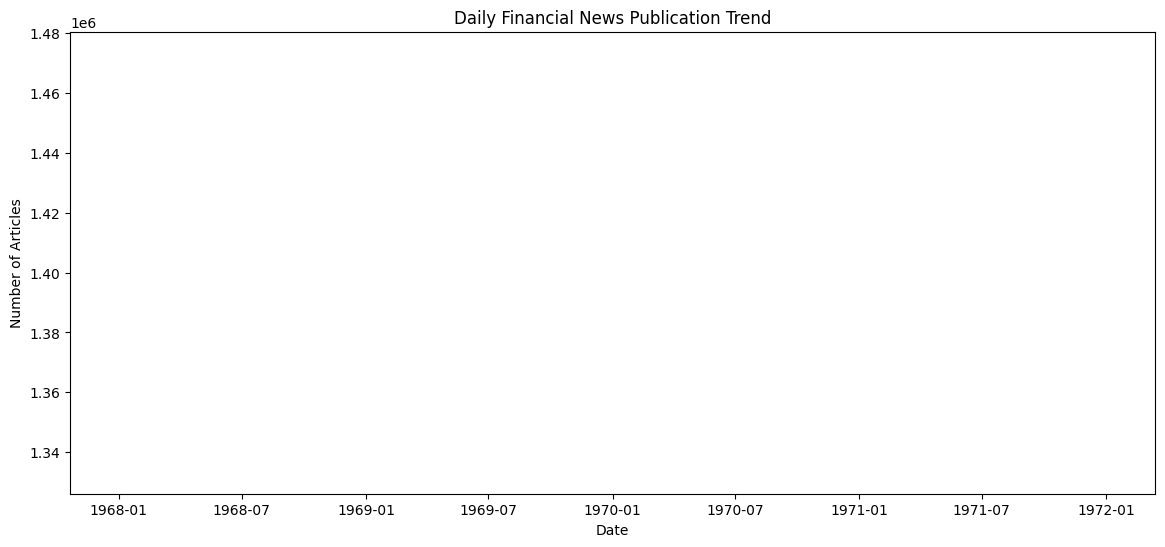

In [ ]:
plt.figure(figsize=(14,6))

daily_news.plot()

plt.title("Daily Financial News Publication Trend")
plt.xlabel("Date")
plt.ylabel("Number of Articles")

plt.show()

In [ ]:
news_df['dt'].head(10)

0   1970-01-01 00:00:00.020200605+00:00
1   1970-01-01 00:00:00.020200603+00:00
2   1970-01-01 00:00:00.020200526+00:00
3   1970-01-01 00:00:00.020200522+00:00
4   1970-01-01 00:00:00.020200522+00:00
5   1970-01-01 00:00:00.020200522+00:00
6   1970-01-01 00:00:00.020200522+00:00
7   1970-01-01 00:00:00.020200522+00:00
8   1970-01-01 00:00:00.020200522+00:00
9   1970-01-01 00:00:00.020200522+00:00
Name: dt, dtype: datetime64[ns, UTC]

In [ ]:
import pandas as pd

In [ ]:
news_df = pd.read_csv(
    "../data/raw/raw_analyst_ratings_compressed.csv",
    engine="python",
    on_bad_lines="skip"
)

news_df.head()

,Unnamed: 0,headline,url,publisher,dt,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,20200605,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,20200603,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,20200526,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,20200522,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,20200522,A


In [ ]:
news_df['dt'].head(10)

0    20200605
1    20200603
2    20200526
3    20200522
4    20200522
5    20200522
6    20200522
7    20200522
8    20200522
9    20200522
Name: dt, dtype: int64

In [ ]:
news_df['dt'] = pd.to_datetime(
    news_df['dt'],
    format='%Y%m%d'
)

In [ ]:
news_df['dt'].head()

0   2020-06-05
1   2020-06-03
2   2020-05-26
3   2020-05-22
4   2020-05-22
Name: dt, dtype: datetime64[us]

In [ ]:
daily_news = news_df.groupby(news_df['dt'].dt.date).size()

In [ ]:
plt.figure(figsize=(14,6))

daily_news.plot()

plt.title("Daily Financial News Publication Trend")
plt.xlabel("Date")
plt.ylabel("Number of Articles")

plt.show()

NameError: name 'plt' is not defined

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

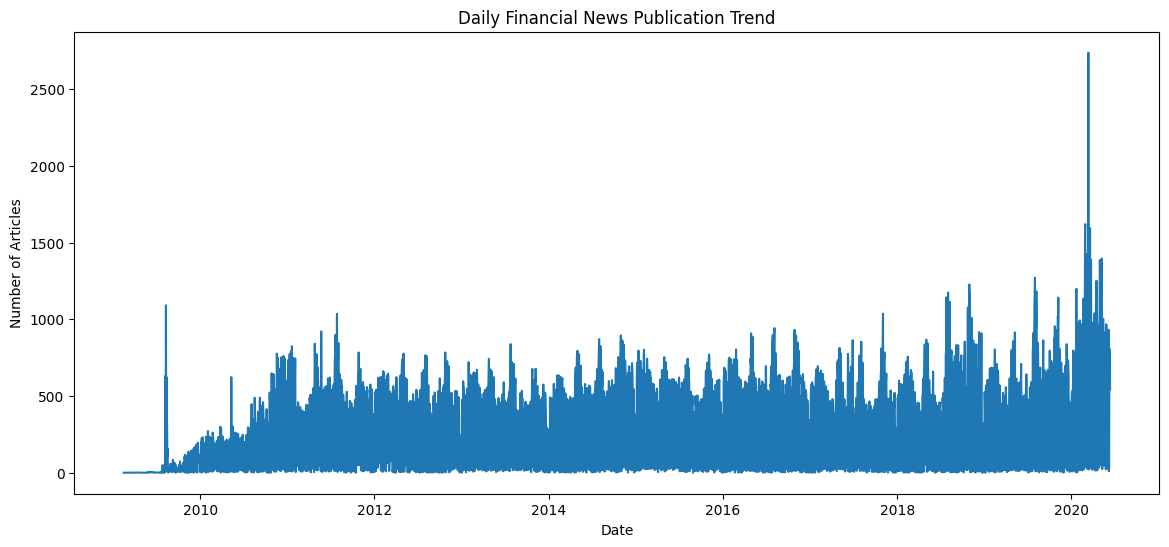

In [ ]:
plt.figure(figsize=(14,6))

daily_news.plot()

plt.title("Daily Financial News Publication Trend")
plt.xlabel("Date")
plt.ylabel("Number of Articles")

plt.show()

In [ ]:
news_df['headline_length'] = news_df['headline'].astype(str).apply(len)

news_df['headline_length'].describe()

count    1.403295e+06
mean     7.301208e+01
std      4.060745e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.090000e+02
Name: headline_length, dtype: float64

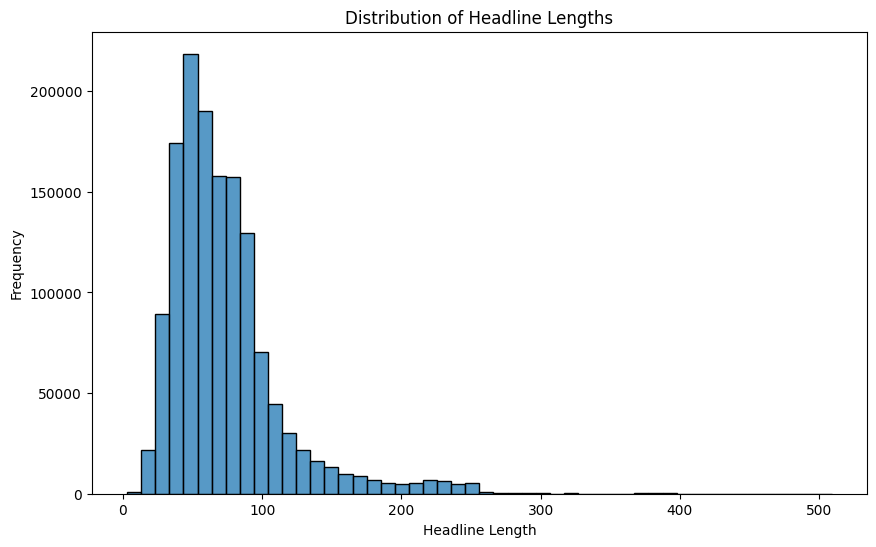

In [ ]:
plt.figure(figsize=(10,6))

sns.histplot(news_df['headline_length'], bins=50)

plt.title("Distribution of Headline Lengths")
plt.xlabel("Headline Length")
plt.ylabel("Frequency")

plt.show()

In [ ]:
publisher_counts = news_df['publisher'].value_counts()

publisher_counts.head(10)

publisher
Paul Quintaro        227837
Lisa Levin           186969
Benzinga Newsdesk    149950
Charles Gross         96516
Monica Gerson         82319
Eddie Staley          57019
Hal Lindon            48722
Juan Lopez            28436
ETF Professor         28385
Benzinga Staff        27929
Name: count, dtype: int64

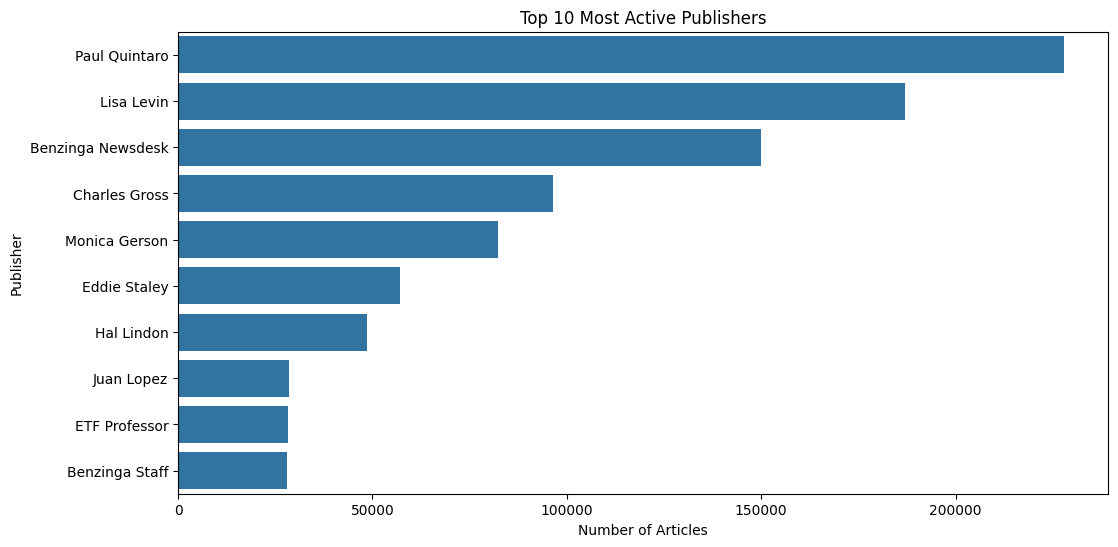

In [ ]:
top_publishers = publisher_counts.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_publishers.values,
    y=top_publishers.index
)

plt.title("Top 10 Most Active Publishers")
plt.xlabel("Number of Articles")
plt.ylabel("Publisher")

plt.show()

In [ ]:
stock_counts = news_df['stock'].value_counts()

stock_counts.head(10)

stock
MRK     3323
MS      3217
MU      3134
NVDA    3132
QQQ     3100
M       3011
NFLX    3007
EBAY    3001
GILD    2950
VZ      2949
Name: count, dtype: int64

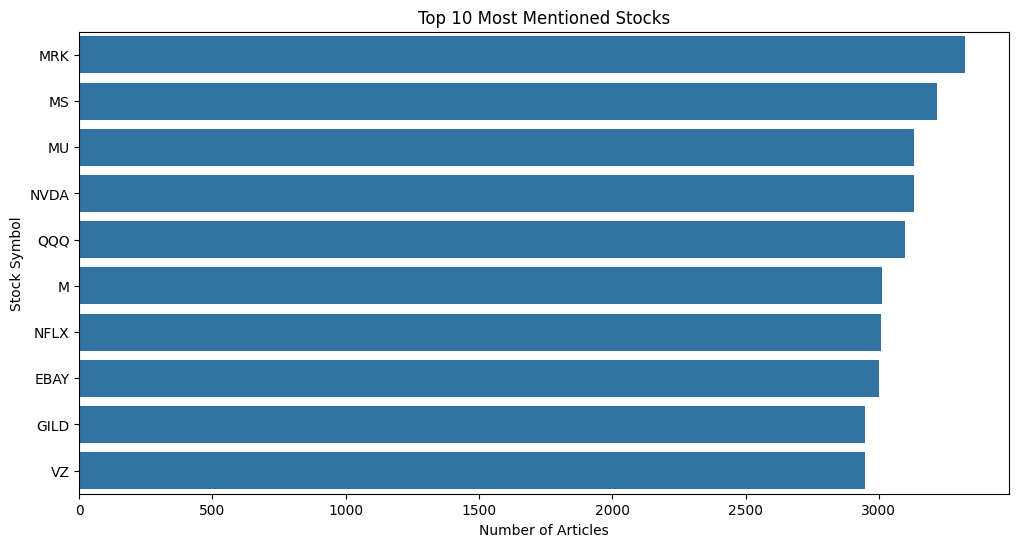

In [ ]:
top_stocks = stock_counts.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_stocks.values,
    y=top_stocks.index
)

plt.title("Top 10 Most Mentioned Stocks")
plt.xlabel("Number of Articles")
plt.ylabel("Stock Symbol")

plt.show()

In [ ]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(
    stop_words='english',
    max_features=20
)

In [ ]:
X = vectorizer.fit_transform(news_df['headline'])

In [ ]:
word_counts = pd.DataFrame({
    'word': vectorizer.get_feature_names_out(),
    'count': X.toarray().sum(axis=0)
})

word_counts = word_counts.sort_values(
    by='count',
    ascending=False
)

word_counts

,word,count
18,vs,162068
15,stocks,161661
6,est,140589
5,eps,128869
7,market,120336
14,shares,113976
12,reports,108617
17,update,91477
4,earnings,87324
13,sales,79578


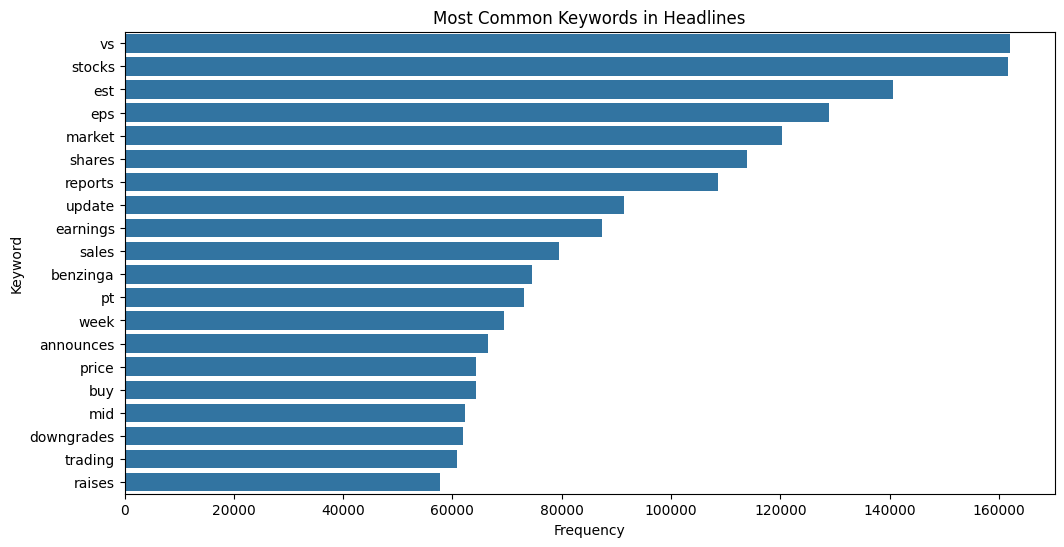

In [ ]:
plt.figure(figsize=(12,6))

sns.barplot(
    x='count',
    y='word',
    data=word_counts
)

plt.title("Most Common Keywords in Headlines")
plt.xlabel("Frequency")
plt.ylabel("Keyword")

plt.show()

## Key Insight

The most common headline keywords are strongly related to:
- stock performance
- earnings reports
- analyst ratings
- market movement

This suggests that the dataset is heavily concentrated around financial performance reporting and market sentiment.